## Stats, Trends and Validations ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [2]:
df = pd.read_csv('../data/cleaned_data.csv')
df.head()

,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,...,notification_response_rate,account_creation_year,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,linked_accounts_count,subscription_status,user_engagement_score
0,37,Female,Brazil,Urban,High,Student,Some college,Single,No,9.2,...,0.64,2016,2025-04-15,21.3,Reels,Music,Public,1,Free,1.07
1,45,Female,Germany,Urban,Lower-middle,Full-time employed,High school,Married,Yes,3.5,...,0.04,2015,2025-11-11,16.0,Live,Travel,Private,0,Free,1.22
2,22,Male,Germany,Urban,Upper-middle,Freelancer,Bachelor’s,Relationship,No,9.4,...,0.33,2017,2025-05-25,13.9,Photos,Tech,Public,1,Free,0.96
3,56,Female,United States,Suburban,Low,Full-time employed,High school,Single,No,7.8,...,0.64,2013,2025-02-26,29.3,Videos,Other,Public,3,Free,1.31
4,60,Male,United States,Urban,Low,Full-time employed,Master’s,Single,No,0.7,...,0.64,2023,2025-02-19,35.1,Reels,Fashion,Friends only,4,Free,0.82


### Generate Summaries for EDA ###

### Hypothesis 1: Age group vs Click Through Rate ###

In [4]:
# Create age bins
df['age_group'] = pd.cut(df['age'], 
                         bins=[0, 25, 35, 50, 100], 
                         labels=['18-25', '26-35', '36-50', '50+'])

# Check the distribution
print(df['age_group'].value_counts().sort_index())

age_group
18-25    50
26-35    43
36-50    50
50+      57
Name: count, dtype: int64


To make the results easier to understand, I grouped people into age ranges instead of using every exact age.
This helps us compare patterns clearly, like whether younger or older users are more likely to click ads.

Using age bins also reduces noise in the data, so trends are easier to spot in charts and tables

  age_group  impressions  clicks       ctr  ctr_percent
0     18-25           50     228  4.560000   456.000000
1     26-35           43     210  4.883721   488.372093
2     36-50           50     257  5.140000   514.000000
3       50+           57     246  4.315789   431.578947


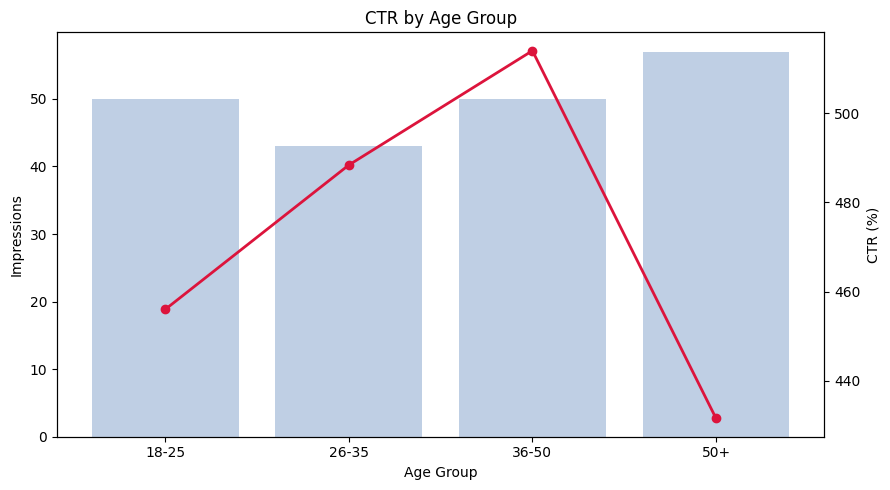

In [5]:
click_col = 'ads_clicked_per_day'

# Use existing age_group
age_ctr = (
    df.groupby('age_group', observed=False)[click_col]
      .agg(impressions='count', clicks='sum')
      .reset_index()
)

age_ctr['ctr'] = age_ctr['clicks'] / age_ctr['impressions']
age_ctr['ctr_percent'] = age_ctr['ctr'] * 100

print(age_ctr)

# Plot: histogram-style bars (impressions) + CTR line
fig, ax1 = plt.subplots(figsize=(9,5))

ax1.bar(age_ctr['age_group'].astype(str), age_ctr['impressions'], color='lightsteelblue', alpha=0.8)
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Impressions')

ax2 = ax1.twinx()
ax2.plot(age_ctr['age_group'].astype(str), age_ctr['ctr_percent'], marker='o', color='crimson', linewidth=2)
ax2.set_ylabel('CTR (%)')

plt.title('CTR by Age Group')
plt.tight_layout()
plt.show()

In [6]:
# Statistical test for Hypothesis 1: compare CTR across age groups
from scipy.stats import kruskal

# Rebuild per-user click-through rate and avoid divide-by-zero
rate_df = df[['age_group', 'ads_clicked_per_day', 'ads_viewed_per_day']].copy()
rate_df['ctr'] = rate_df['ads_clicked_per_day'] / rate_df['ads_viewed_per_day'].replace(0, np.nan)
rate_df = rate_df.dropna(subset=['ctr'])

grouped_ctr = [group['ctr'].dropna().values for _, group in rate_df.groupby('age_group', observed=False)]
h_stat, p_value = kruskal(*grouped_ctr)

print(f'Kruskal-Wallis test for CTR across age groups: H = {h_stat:.3f}, p-value = {p_value:.6f}')

if p_value < 0.05:
    print('Result: CTR differs significantly across age groups.')
else:
    print('Result: No statistically significant difference in CTR across age groups.')

Kruskal-Wallis test for CTR across age groups: H = 1.282, p-value = 0.733385
Result: No statistically significant difference in CTR across age groups.


Upon doing this statistcal test, it shows the relationship between click-through and age group is not statistically  significant, therefore marketing agencies should not focus on age in their marketing stategy.

This graph in the (blue columns) show the age ranges, whilst the (red line) shows how much those people clicke ads on average.

This shows us that the click rate starts to decline from 50+. This indicates that the age group ads should really start to target are the 26-50 range, anything after those ages would be redundant.

### Hypothesis 2: Comparison-Driven Ad Engagement ###

Users with a low follower-to-following ratio (high content consumption, low content creation) may click more ads because they are more exposed to aspirational lifestyle content.

In this analysis, low-ratio users are treated as Lurkers and high-ratio users are treated as Creators. We test whether Lurkers show significantly higher ads_clicked_per_day.

Layman meaning: people who follow many accounts but have fewer followers themselves (Lurkers) may click ads more often because they are constantly exposed to aspirational content and products.

Summary by follower-to-following segment:
     comparison_segment  count  mean_clicks  median_clicks
0    Lurker (Low Ratio)     60     4.566667            4.0
1                Middle     80     4.937500            4.0
2  Creator (High Ratio)     60     4.533333            4.0


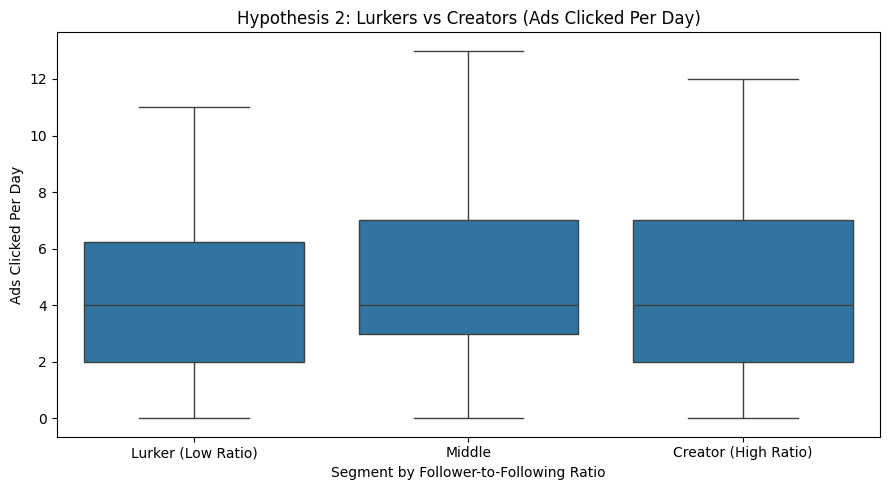

Spearman rho (ratio vs ads_clicked_per_day) = -0.049, p-value = 0.495215
Mann-Whitney U test (Lurkers > Creators): U = 1804.00, p-value = 0.492632
Result: No significant evidence that Lurkers click more ads than Creators.


In [11]:
# Hypothesis 2 test: Comparison-Driven Ad Engagement (Lurkers vs Creators)
from scipy.stats import mannwhitneyu, spearmanr

target = 'ads_clicked_per_day'

# Build ratio safely (add 1 to avoid divide-by-zero)
df['follower_following_ratio'] = df['followers_count'] / (df['following_count'] + 1)

# Create behavior segments from ratio quantiles
low_cut = df['follower_following_ratio'].quantile(0.30)
high_cut = df['follower_following_ratio'].quantile(0.70)

df['comparison_segment'] = np.where(
    df['follower_following_ratio'] <= low_cut, 'Lurker (Low Ratio)',
    np.where(df['follower_following_ratio'] >= high_cut, 'Creator (High Ratio)', 'Middle')
)

segment_summary = (
    df.groupby('comparison_segment', observed=False)[target]
      .agg(count='count', mean_clicks='mean', median_clicks='median')
      .reindex(['Lurker (Low Ratio)', 'Middle', 'Creator (High Ratio)'])
      .reset_index()
)

print('Summary by follower-to-following segment:')
print(segment_summary)

# Visual check
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x='comparison_segment',
    y=target,
    order=['Lurker (Low Ratio)', 'Middle', 'Creator (High Ratio)']
)
plt.title('Hypothesis 2: Lurkers vs Creators (Ads Clicked Per Day)')
plt.xlabel('Segment by Follower-to-Following Ratio')
plt.ylabel('Ads Clicked Per Day')
plt.tight_layout()
plt.show()

# Correlation check (monotonic trend)
rho, p_corr = spearmanr(df['follower_following_ratio'], df[target], nan_policy='omit')
print(f'Spearman rho (ratio vs {target}) = {rho:.3f}, p-value = {p_corr:.6f}')

# One-sided significance test for your hypothesis: Lurkers > Creators
lurker_clicks = df.loc[df['comparison_segment'] == 'Lurker (Low Ratio)', target].dropna()
creator_clicks = df.loc[df['comparison_segment'] == 'Creator (High Ratio)', target].dropna()

u_stat, p_mwu = mannwhitneyu(lurker_clicks, creator_clicks, alternative='greater')
print(f'Mann-Whitney U test (Lurkers > Creators): U = {u_stat:.2f}, p-value = {p_mwu:.6f}')

if p_mwu < 0.05:
    print('Result: Significant evidence that Lurkers click more ads than Creators.')
else:
    print('Result: No significant evidence that Lurkers click more ads than Creators.')

### Hypothesis 3: Behavioral Activity Pattern ###

Using features: ['daily_active_minutes_instagram', 'sessions_per_day', 'posts_created_per_week', 'reels_watched_per_day', 'stories_viewed_per_day', 'likes_given_per_day', 'comments_written_per_day', 'dms_sent_per_week', 'time_on_feed_per_day', 'time_on_reels_per_day', 'average_session_length_minutes', 'user_engagement_score']

Correlation with ads_clicked_per_day:
daily_active_minutes_instagram    0.682204
likes_given_per_day               0.669317
time_on_feed_per_day              0.653740
stories_viewed_per_day            0.652372
time_on_reels_per_day             0.646737
comments_written_per_day          0.639103
dms_sent_per_week                 0.617247
reels_watched_per_day             0.560842
sessions_per_day                  0.544997
posts_created_per_week            0.307261
average_session_length_minutes    0.081556
user_engagement_score            -0.375895
Name: ads_clicked_per_day, dtype: float64

Ads clicked per day by activity level:
  activity_level  count  mean_click

C:\Users\faiza\AppData\Local\Temp\ipykernel_19980\3200336150.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


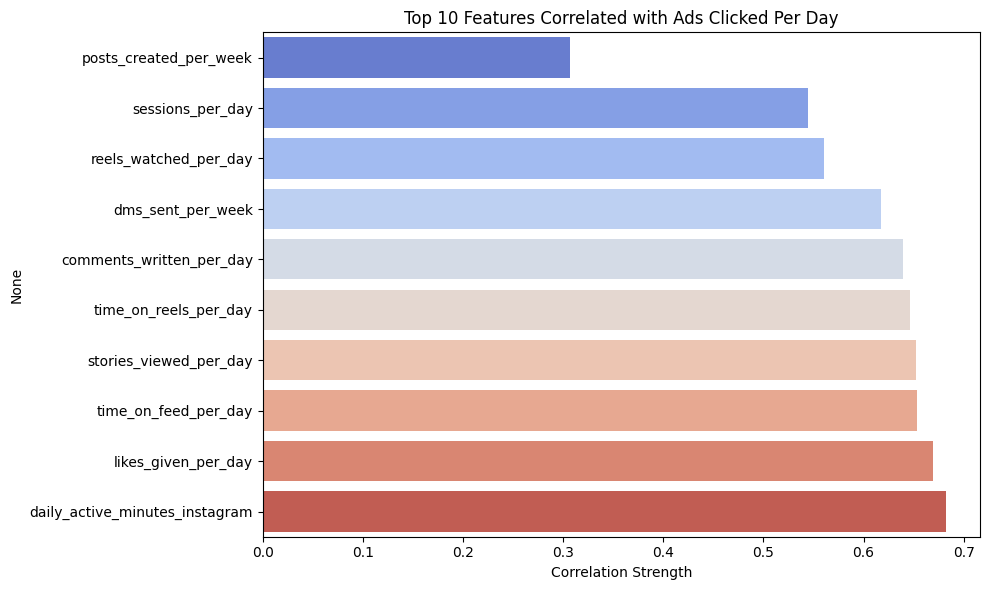


Spearman correlation (activity_score vs ads_clicked_per_day): rho=0.672, p-value=1.225e-27
Result: Statistically significant relationship found.


In [7]:
# Hypothesis 3: Higher Instagram activity -> more ads clicked per day

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

target = "ads_clicked_per_day"

# Engagement/activity features available in your dataset
activity_features = [
    "daily_active_minutes_instagram",
    "sessions_per_day",
    "posts_created_per_week",
    "reels_watched_per_day",
    "stories_viewed_per_day",
    "likes_given_per_day",
    "comments_written_per_day",
    "dms_sent_per_week",
    "time_on_feed_per_day",
    "time_on_reels_per_day",
    "average_session_length_minutes",
    "user_engagement_score"
]

# Keep only columns that actually exist
activity_features = [c for c in activity_features if c in df.columns]
print("Using features:", activity_features)

# 1) Correlation table with target (exclude target self-correlation)
corr = df[activity_features + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)
corr = corr.drop(labels=[target], errors="ignore")
print("\nCorrelation with ads_clicked_per_day:")
print(corr)

# 2) Build a combined activity score (z-score average)
z = df[activity_features].apply(lambda s: (s - s.mean()) / s.std(ddof=0))
df["activity_score"] = z.mean(axis=1)

# Create activity groups: Low / Medium / High
df["activity_level"] = pd.qcut(
    df["activity_score"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

# 3) Compare ad clicks across activity groups
summary = (
    df.groupby("activity_level", observed=False)[target]
      .agg(count="count", mean_clicks="mean", median_clicks="median")
      .reset_index()
)
print("\nAds clicked per day by activity level:")
print(summary)

# 4) Visualize: top 10 correlated features
plt.figure(figsize=(10, 6))
top_corr = corr.head(10).sort_values()
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title('Top 10 Features Correlated with Ads Clicked Per Day')
plt.xlabel('Correlation Strength')
plt.tight_layout()
plt.show()

# 5) Statistical check (Spearman rank correlation)
rho, p = spearmanr(df["activity_score"], df[target], nan_policy="omit")
print(f"\nSpearman correlation (activity_score vs {target}): rho={rho:.3f}, p-value={p:.3e}")

if p < 0.05:
    print("Result: Statistically significant relationship found.")
else:
    print("Result: No statistically significant relationship found.")

In [9]:
# Full exploratory comparison: ads_clicked_per_day vs all other features
from scipy.stats import kruskal, spearmanr

target = 'ads_clicked_per_day'

# ---------- Numeric features: Spearman correlation ----------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target]

num_results = []
for col in num_cols:
    tmp = df[[col, target]].dropna()
    if tmp[col].nunique() < 2:
        continue
    rho, pval = spearmanr(tmp[col], tmp[target])
    num_results.append({
        'feature': col,
        'test': 'Spearman',
        'effect': rho,
        'p_value': pval
    })

num_results_df = pd.DataFrame(num_results).sort_values('p_value')

# ---------- Categorical features: Kruskal-Wallis ----------
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
cat_results = []
for col in cat_cols:
    tmp = df[[col, target]].dropna()
    groups = [g[target].values for _, g in tmp.groupby(col, observed=False) if len(g) >= 2]
    if len(groups) < 2:
        continue
    try:
        h_stat, pval = kruskal(*groups)
        cat_results.append({
            'feature': col,
            'test': 'Kruskal-Wallis',
            'effect': h_stat,
            'p_value': pval,
            'n_groups': tmp[col].nunique()
        })
    except Exception:
        continue

cat_results_df = pd.DataFrame(cat_results).sort_values('p_value')

print('Full exploratory comparison against ads_clicked_per_day')
print(f"Numeric features tested: {len(num_results_df)}")
print(f"Categorical features tested: {len(cat_results_df)}")

print('\nTop 10 numeric features by smallest p-value:')
print(num_results_df[['feature', 'effect', 'p_value']].head(10).to_string(index=False))

print('\nTop 10 categorical features by smallest p-value:')
if len(cat_results_df) > 0:
    print(cat_results_df[['feature', 'effect', 'p_value', 'n_groups']].head(10).to_string(index=False))
else:
    print('No categorical tests available.')

# Combined ranked table for reporting
all_results_df = pd.concat([
    num_results_df[['feature', 'test', 'effect', 'p_value']],
    cat_results_df[['feature', 'test', 'effect', 'p_value']]
], ignore_index=True).sort_values('p_value')

print('\nTop 20 overall associations (all feature types):')
print(all_results_df.head(20).to_string(index=False))

Full exploratory comparison against ads_clicked_per_day
Numeric features tested: 34
Categorical features tested: 16

Top 10 numeric features by smallest p-value:
                       feature   effect      p_value
daily_active_minutes_instagram 0.683969 6.249725e-29
           likes_given_per_day 0.676607 4.001513e-28
            ads_viewed_per_day 0.675027 5.918682e-28
                activity_score 0.672064 1.225257e-27
         time_on_reels_per_day 0.670716 1.701256e-27
      time_on_messages_per_day 0.667140 4.030245e-27
          time_on_feed_per_day 0.659761 2.301372e-26
        stories_viewed_per_day 0.657825 3.606585e-26
      comments_written_per_day 0.647611 3.652633e-25
              sessions_per_day 0.629338 1.857306e-23

Top 10 categorical features by smallest p-value:
                feature    effect      p_value  n_groups
         activity_level 83.387670 7.809038e-19         3
           income_level 15.639530 3.543041e-03         5
           diet_quality  7.410425 

### Full Exploratory Check (All Features) ###

To complement the focused Hypothesis 3 test, I also ran a full exploratory comparison of ads_clicked_per_day against all other variables.

- Numeric variables were tested using Spearman correlation.
- Categorical variables were tested using Kruskal-Wallis.
- Results are ranked by p-value to show which features are most strongly associated with ad clicks.

This lets us report both:
1. A targeted hypothesis test (activity_score vs ads_clicked_per_day).
2. A broader exploratory scan across the full dataset.

We wanted to analyse how user behvioural patterns influence their ad clicking likelihood. 

We hypothesied that daily active minutes on Instagram would be a better metric to predict ad engagement than the amount of Instagram reels watched. This is proven to be true, as shown on the colour coded chart above.